In [1]:
%pip install numpy scipy pillow matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Question (1)

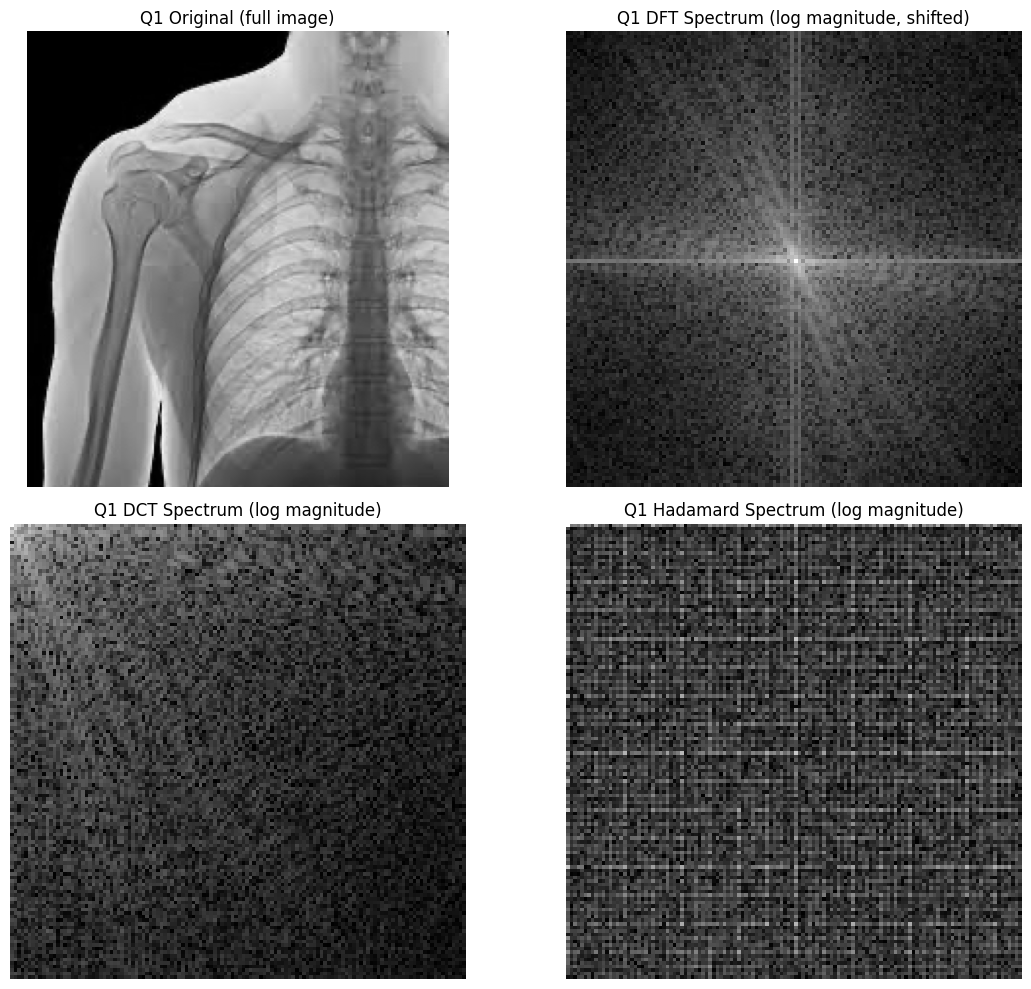

array([[9.64191e-01, 9.88202e-01, 9.93981e-01, 1.58700e-03],
       [9.73637e-01, 9.91494e-01, 9.95650e-01, 6.71000e-04],
       [9.61817e-01, 9.85227e-01, 9.91746e-01, 1.22100e-03]])

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fft import fft2, fftshift, dctn
from scipy.linalg import hadamard


q1_image_path = Path("images/2F0BA7F1-AB57-4378-8F1F-F110B7C4DC6F.jpg.jpeg")
q1_pil = Image.open(q1_image_path).convert("L")
q1_img_full = np.array(q1_pil, dtype=np.float64)

# Hadamard needs power-of-two size, so resize full image to NxN
q1_N = 2 ** int(np.floor(np.log2(min(q1_img_full.shape))))
q1_resample = Image.Resampling.BICUBIC if hasattr(Image, "Resampling") else Image.BICUBIC
q1_img_n = np.array(q1_pil.resize((q1_N, q1_N), q1_resample), dtype=np.float64)

# transforms
q1_F = fft2(q1_img_n, norm="ortho")
q1_F_spectrum = np.log1p(np.abs(fftshift(q1_F)))

q1_C = dctn(q1_img_n, type=2, norm="ortho")
q1_C_spectrum = np.log1p(np.abs(q1_C))

q1_H = hadamard(q1_N).astype(np.float64) / np.sqrt(q1_N)
q1_W = q1_H @ q1_img_n @ q1_H
q1_W_spectrum = np.log1p(np.abs(q1_W))

# spectra visualization
q1_fig, q1_axes = plt.subplots(2, 2, figsize=(12, 10))

q1_axes[0, 0].imshow(q1_img_full, cmap="gray")
q1_axes[0, 0].set_title("Q1 Original (full image)")
q1_axes[0, 0].axis("off")

q1_axes[0, 1].imshow(q1_F_spectrum, cmap="gray")
q1_axes[0, 1].set_title("Q1 DFT Spectrum (log magnitude, shifted)")
q1_axes[0, 1].axis("off")

q1_axes[1, 0].imshow(q1_C_spectrum, cmap="gray")
q1_axes[1, 0].set_title("Q1 DCT Spectrum (log magnitude)")
q1_axes[1, 0].axis("off")

q1_axes[1, 1].imshow(q1_W_spectrum, cmap="gray")
q1_axes[1, 1].set_title("Q1 Hadamard Spectrum (log magnitude)")
q1_axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# energy concentration numbers (rows: DFT, DCT, Hadamard; cols: top1, top5, top10, frac90)
q1_fractions = np.array([0.01, 0.05, 0.10])

q1_dft_energy = np.sort((np.abs(q1_F) ** 2).ravel())[::-1]
q1_dct_energy = np.sort((np.abs(q1_C) ** 2).ravel())[::-1]
q1_had_energy = np.sort((np.abs(q1_W) ** 2).ravel())[::-1]

q1_dft_total = q1_dft_energy.sum()
q1_dct_total = q1_dct_energy.sum()
q1_had_total = q1_had_energy.sum()

q1_dft_top = [q1_dft_energy[:max(1, int(np.ceil(f * q1_dft_energy.size)))].sum() / q1_dft_total for f in q1_fractions]
q1_dct_top = [q1_dct_energy[:max(1, int(np.ceil(f * q1_dct_energy.size)))].sum() / q1_dct_total for f in q1_fractions]
q1_had_top = [q1_had_energy[:max(1, int(np.ceil(f * q1_had_energy.size)))].sum() / q1_had_total for f in q1_fractions]

q1_dft_frac90 = (np.searchsorted(np.cumsum(q1_dft_energy), 0.90 * q1_dft_total) + 1) / q1_dft_energy.size
q1_dct_frac90 = (np.searchsorted(np.cumsum(q1_dct_energy), 0.90 * q1_dct_total) + 1) / q1_dct_energy.size
q1_had_frac90 = (np.searchsorted(np.cumsum(q1_had_energy), 0.90 * q1_had_total) + 1) / q1_had_energy.size

q1_energy_numbers = np.array(
    [
        [q1_dft_top[0], q1_dft_top[1], q1_dft_top[2], q1_dft_frac90],
        [q1_dct_top[0], q1_dct_top[1], q1_dct_top[2], q1_dct_frac90],
        [q1_had_top[0], q1_had_top[1], q1_had_top[2], q1_had_frac90],
    ],
    dtype=np.float64,
)
q1_energy_numbers = np.round(q1_energy_numbers, 6)
q1_energy_numbers

DCT wins.

Using our row order DFT, DCT, Hadamard and columns top1, top5, top10, frac90:

Top 1 percent energy: DCT has 0.973637 (highest)
Top 5 percent energy: DCT has 0.991494 (highest)
Top 10 percent energy: DCT has 0.995650 (highest)
Fraction needed for 90 percent energy: DCT has 0.000671 (lowest, so best)


# Question (2)

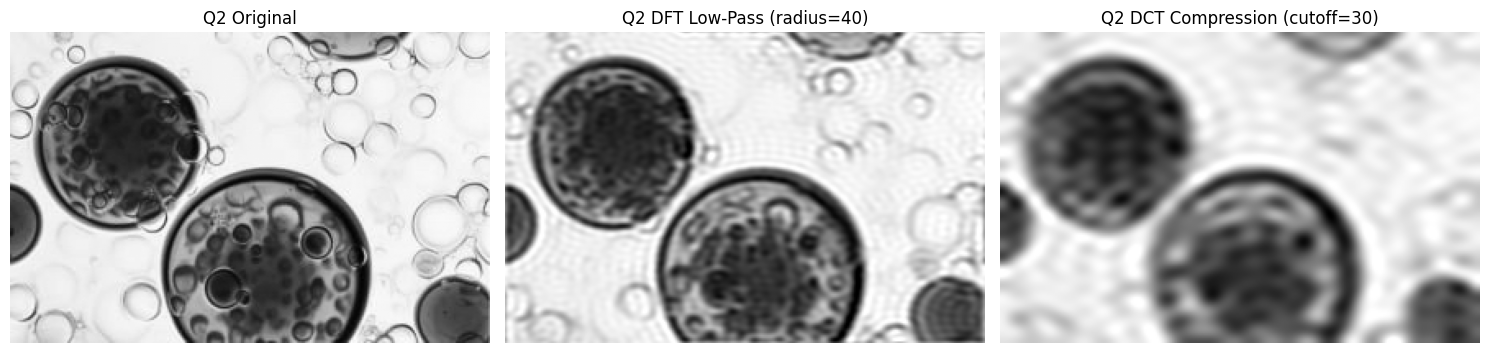

In [3]:
from scipy.fft import ifft2, ifftshift, idctn


q2_image_path = Path("images/63378AE6-0025-4267-B6CA-2F0FAFA8ED9E.jpg.jpeg")
q2_img = np.array(Image.open(q2_image_path).convert("L"), dtype=np.float64)


# Task 1: low-pass filtering in frequency domain with cutoff radius = 40 (DFT)
q2_cutoff_lp = 40
q2_F = fft2(q2_img)
q2_F_shift = fftshift(q2_F)

q2_rows, q2_cols = q2_img.shape
q2_crow, q2_ccol = q2_rows // 2, q2_cols // 2
q2_Y, q2_X = np.ogrid[:q2_rows, :q2_cols]
q2_lp_mask = ((q2_Y - q2_crow) ** 2 + (q2_X - q2_ccol) ** 2) <= (q2_cutoff_lp ** 2)

q2_F_low = q2_F_shift * q2_lp_mask
q2_img_lowpass = np.real(ifft2(ifftshift(q2_F_low)))
q2_img_lowpass = np.clip(q2_img_lowpass, 0, 255)


# Task 2: compression by removing high-frequency components beyond cutoff = 30 (DCT)
q2_cutoff_comp = 30
q2_C = dctn(q2_img, type=2, norm="ortho")

q2_dct_mask = np.zeros_like(q2_C, dtype=np.float64)
q2_dct_mask[:q2_cutoff_comp, :q2_cutoff_comp] = 1.0

q2_C_comp = q2_C * q2_dct_mask
q2_img_compressed = idctn(q2_C_comp, type=2, norm="ortho")
q2_img_compressed = np.clip(q2_img_compressed, 0, 255)


# Visualization
q2_fig, q2_axes = plt.subplots(1, 3, figsize=(15, 5))

q2_axes[0].imshow(q2_img, cmap="gray")
q2_axes[0].set_title("Q2 Original")
q2_axes[0].axis("off")

q2_axes[1].imshow(q2_img_lowpass, cmap="gray")
q2_axes[1].set_title("Q2 DFT Low-Pass (radius=40)")
q2_axes[1].axis("off")

q2_axes[2].imshow(q2_img_compressed, cmap="gray")
q2_axes[2].set_title("Q2 DCT Compression (cutoff=30)")
q2_axes[2].axis("off")

plt.tight_layout()
plt.show()

# Question (3)

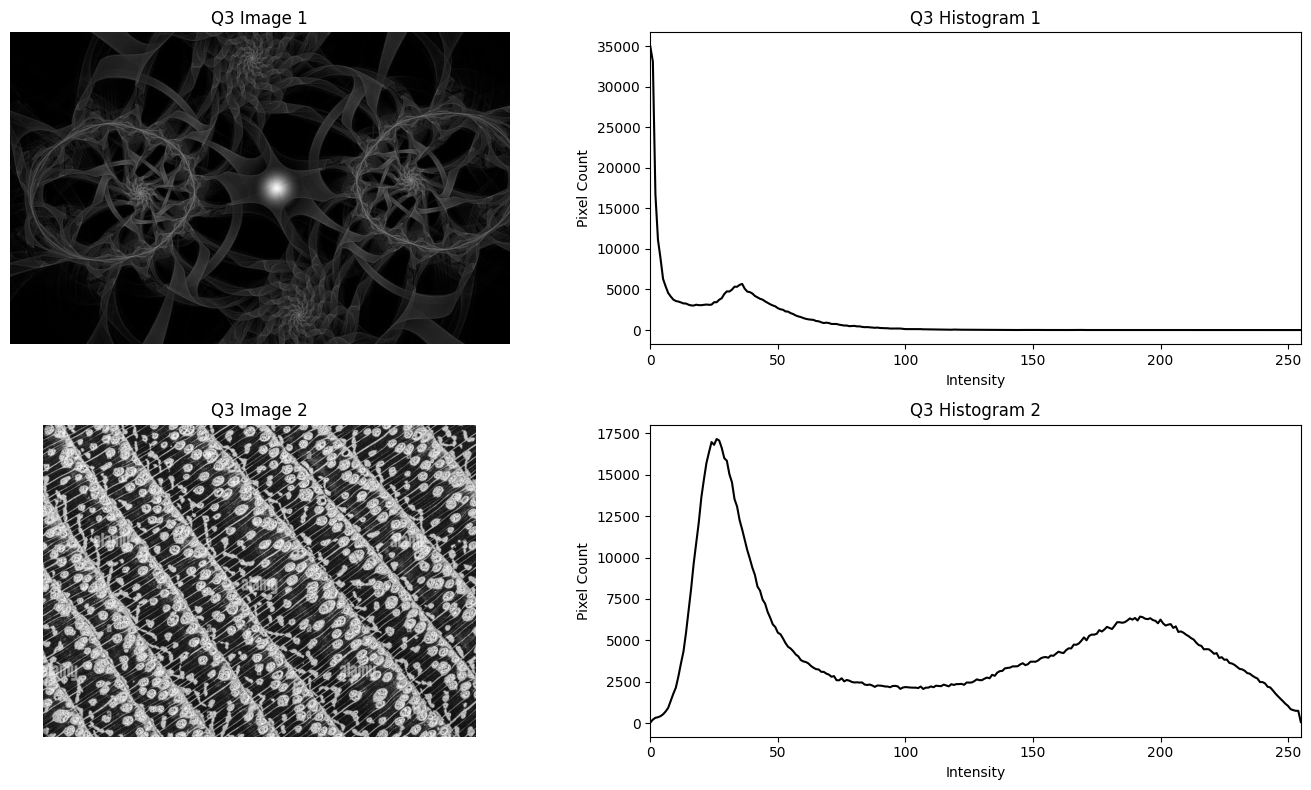

In [4]:
q3_image_path_1 = Path("images/A352AC59-2E98-444E-B4D4-96CC7F4E32B8.jpg.jpeg")
q3_image_path_2 = Path("images/5A06309F-595F-4ACA-B920-6237A498E97E.jpg.jpeg")

q3_img1 = np.array(Image.open(q3_image_path_1).convert("L"), dtype=np.uint8)
q3_img2 = np.array(Image.open(q3_image_path_2).convert("L"), dtype=np.uint8)

q3_hist1, q3_bins1 = np.histogram(q3_img1.ravel(), bins=256, range=(0, 256))
q3_hist2, q3_bins2 = np.histogram(q3_img2.ravel(), bins=256, range=(0, 256))

q3_fig, q3_axes = plt.subplots(2, 2, figsize=(14, 8))

q3_axes[0, 0].imshow(q3_img1, cmap="gray", vmin=0, vmax=255)
q3_axes[0, 0].set_title("Q3 Image 1")
q3_axes[0, 0].axis("off")

q3_axes[0, 1].plot(q3_bins1[:-1], q3_hist1, color="black")
q3_axes[0, 1].set_title("Q3 Histogram 1")
q3_axes[0, 1].set_xlim(0, 255)
q3_axes[0, 1].set_xlabel("Intensity")
q3_axes[0, 1].set_ylabel("Pixel Count")

q3_axes[1, 0].imshow(q3_img2, cmap="gray", vmin=0, vmax=255)
q3_axes[1, 0].set_title("Q3 Image 2")
q3_axes[1, 0].axis("off")

q3_axes[1, 1].plot(q3_bins2[:-1], q3_hist2, color="black")
q3_axes[1, 1].set_title("Q3 Histogram 2")
q3_axes[1, 1].set_xlim(0, 255)
q3_axes[1, 1].set_xlabel("Intensity")
q3_axes[1, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

Image 1: Dark, Low contrast
Image 2: Bright, High contrast

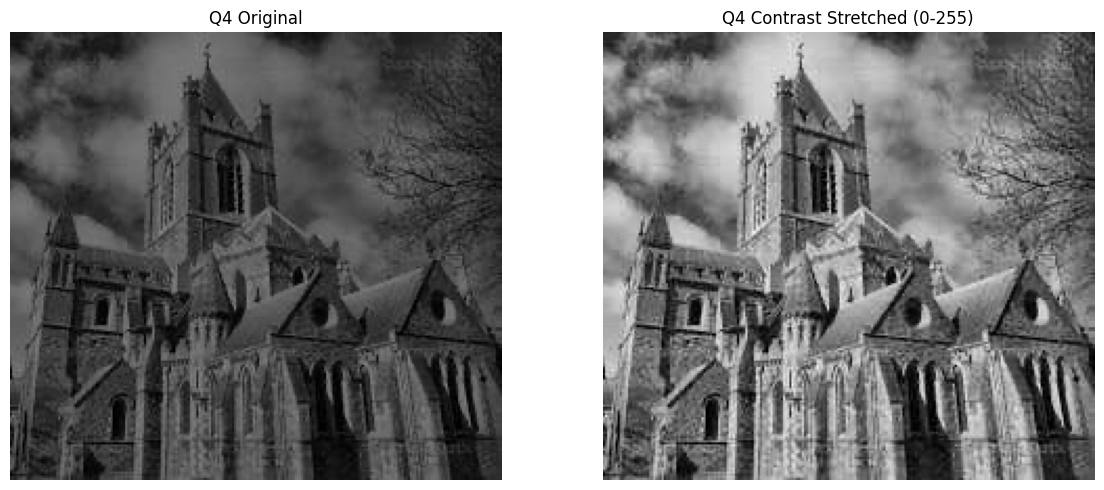

In [5]:
q4_image_path = Path("images/FB7A9C11-1210-4ECB-8DC9-A9706C626BF2.jpg.jpeg")
q4_img = np.array(Image.open(q4_image_path).convert("L"), dtype=np.float64)

# Contrast stretching / normalization to full [0, 255]
q4_min = q4_img.min()
q4_max = q4_img.max()
q4_stretched = (q4_img - q4_min) * (255.0 / (q4_max - q4_min))
q4_stretched = np.clip(q4_stretched, 0, 255).astype(np.uint8)

# Display original and contrast-stretched images
q4_fig, q4_axes = plt.subplots(1, 2, figsize=(12, 5))

q4_axes[0].imshow(q4_img, cmap="gray", vmin=0, vmax=255)
q4_axes[0].set_title("Q4 Original")
q4_axes[0].axis("off")

q4_axes[1].imshow(q4_stretched, cmap="gray", vmin=0, vmax=255)
q4_axes[1].set_title("Q4 Contrast Stretched (0-255)")
q4_axes[1].axis("off")

plt.tight_layout()
plt.show()